📥 Carregando os dados tratados da Parte 1...
✅ Coluna 'customerID' removida.

📊 Gerando gráficos de correlação e dispersão...


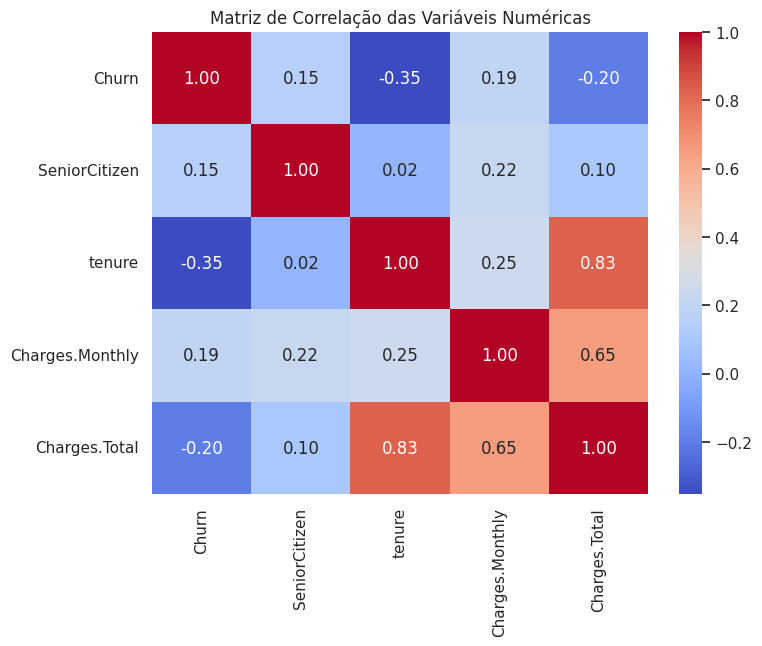

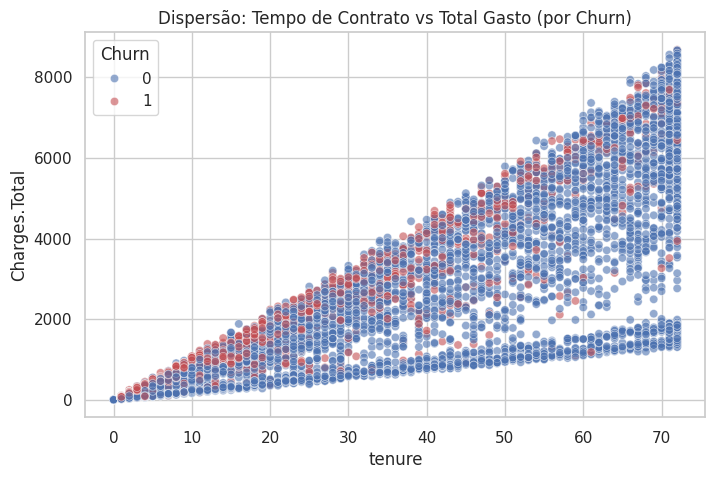


⚙️ Aplicando One-Hot Encoding e Balanceamento (SMOTE)...
Proporção original do Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

Proporção após SMOTE:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64

🤖 Treinando modelos...

--- Resultados: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1588
           1       0.82      0.83      0.82      1517

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105

--- Resultados: Random Forest ---
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1588
           1       0.80      0.86      0.83      1517

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105



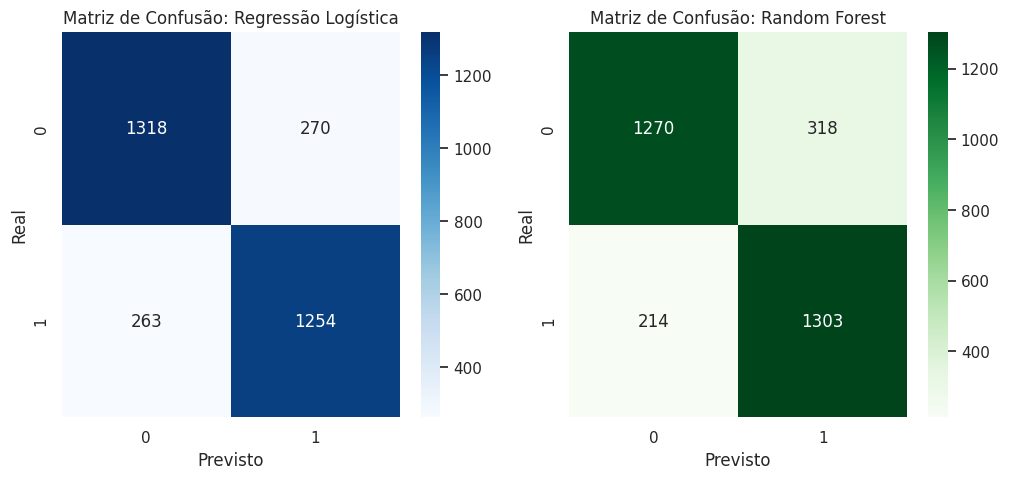


🔍 Analisando as variáveis mais importantes...


/tmp/ipykernel_1235/70536665.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Coeficiente', y='Variável', palette='vlag', ax=axes[0])
/tmp/ipykernel_1235/70536665.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importances, x='Importância', y='Variável', palette='viridis', ax=axes[1])


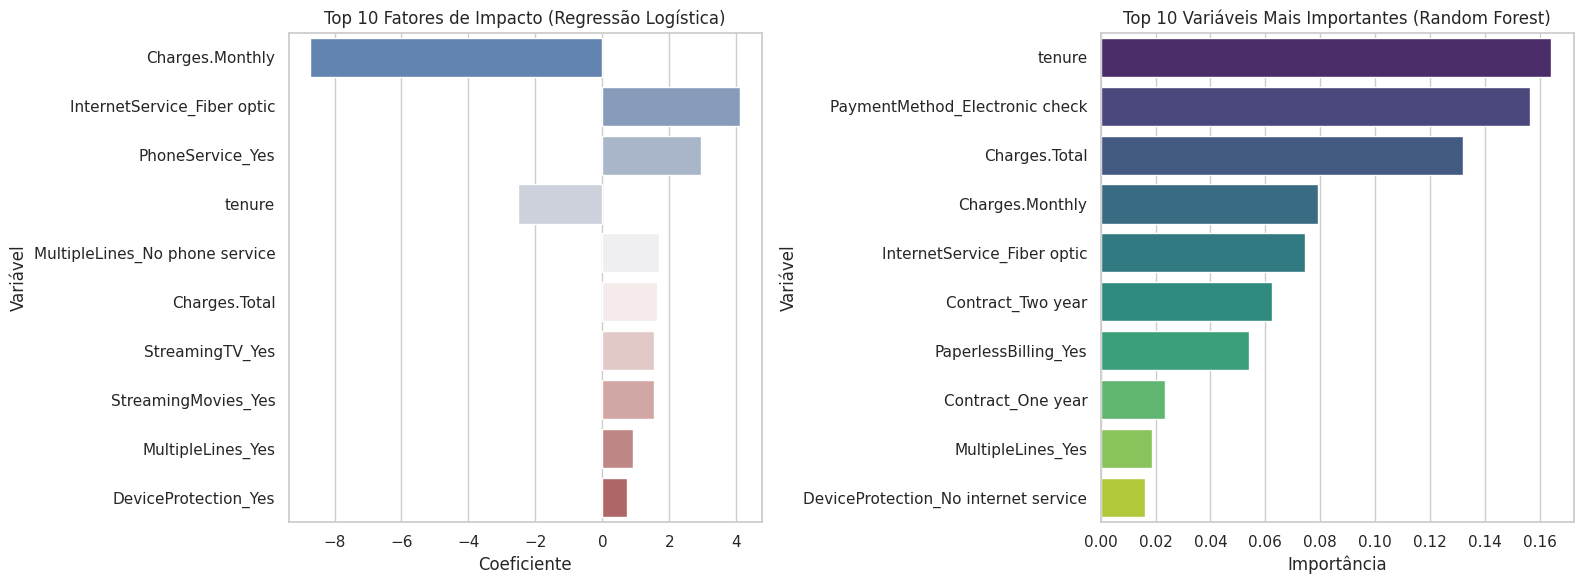

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Configuração visual
sns.set_theme(style="whitegrid")

# ==========================================
# 1. CARREGAMENTO DOS DADOS E LIMPEZA INICIAL
# ==========================================
print("📥 Carregando os dados tratados da Parte 1...")
# Substitua 'telecom_limpo.csv' pelo nome do arquivo salvo na Parte 1.
# df = pd.read_csv('telecom_limpo.csv')

# Como não tenho seu CSV local, vou simular o dataframe limpo da parte 1
# a partir da URL original para que o código rode perfeitamente aí também!
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"
df_raw = pd.read_json(url)
df = pd.concat([df_raw.drop(columns=['customer', 'phone', 'internet', 'account']),
                pd.json_normalize(df_raw['customer']), pd.json_normalize(df_raw['phone']),
                pd.json_normalize(df_raw['internet']), pd.json_normalize(df_raw['account'])], axis=1)

df['Charges.Total'] = pd.to_numeric(df['Charges.Total'].replace(r'^\s*$', np.nan, regex=True), errors='coerce').fillna(0)
df = df[df['Churn'].isin(['Yes', 'No'])].drop_duplicates()

# Removendo identificadores únicos (não agregam valor preditivo)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])
    print("✅ Coluna 'customerID' removida.")

# Transformando a variável alvo (Churn) em binária (0 e 1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# ==========================================
# 2. ANÁLISE EXPLORATÓRIA AVANÇADA
# ==========================================
print("\n📊 Gerando gráficos de correlação e dispersão...")

# Identificando variáveis numéricas para correlação
cols_num = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(8, 6))
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

# Gráfico de Dispersão: Tempo de Contrato x Total Gasto
col_tempo = 'tenure'
col_total = 'Charges.Total'
if col_tempo in df.columns and col_total in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col_tempo, y=col_total, hue='Churn', palette=['#4C72B0', '#C44E52'], alpha=0.6)
    plt.title('Dispersão: Tempo de Contrato vs Total Gasto (por Churn)')
    plt.show()

# ==========================================
# 3. ENCODING E BALANCEAMENTO
# ==========================================
print("\n⚙️ Aplicando One-Hot Encoding e Balanceamento (SMOTE)...")

# One-Hot Encoding nas variáveis categóricas (get_dummies)
df_encoded = pd.get_dummies(df, drop_first=True)

# Separando X (features) e y (alvo)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

print(f"Proporção original do Churn:\n{y.value_counts(normalize=True) * 100}")

# Aplicando SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nProporção após SMOTE:\n{y_resampled.value_counts(normalize=True) * 100}")

# ==========================================
# 4. DIVISÃO DE DADOS E NORMALIZAÇÃO
# ==========================================
# Divisão 70/30
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Normalização (apenas para modelos sensíveis à escala, como Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. TREINAMENTO E AVALIAÇÃO DOS MODELOS
# ==========================================
print("\n🤖 Treinando modelos...")

# Modelo 1: Regressão Logística (Usa dados normalizados)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Modelo 2: Random Forest (Não precisa de normalização)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10) # max_depth para evitar overfitting
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n--- Resultados: Regressão Logística ---")
print(classification_report(y_test, y_pred_log))

print("--- Resultados: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

# Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão: Regressão Logística')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusão: Random Forest')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')
plt.show()

# ==========================================
# 6. IMPORTÂNCIA DAS VARIÁVEIS
# ==========================================
print("\n🔍 Analisando as variáveis mais importantes...")

# Coeficientes da Regressão Logística (Impacto positivo vs negativo no Churn)
coef_df = pd.DataFrame({'Variável': X.columns, 'Coeficiente': log_reg.coef_[0]})
coef_df['Abs_Coef'] = coef_df['Coeficiente'].abs()
coef_df = coef_df.sort_values(by='Abs_Coef', ascending=False).head(10)

# Importância do Random Forest
rf_importances = pd.DataFrame({'Variável': X.columns, 'Importância': rf.feature_importances_})
rf_importances = rf_importances.sort_values(by='Importância', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico LogReg
sns.barplot(data=coef_df, x='Coeficiente', y='Variável', palette='vlag', ax=axes[0])
axes[0].set_title('Top 10 Fatores de Impacto (Regressão Logística)')

# Gráfico Random Forest
sns.barplot(data=rf_importances, x='Importância', y='Variável', palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Variáveis Mais Importantes (Random Forest)')

plt.tight_layout()
plt.show()

# Relatório Final: Previsão de Evasão de Clientes (Churn) - Telecom X

## 1. Preparação e Transformação dos Dados
Iniciamos a segunda fase do projeto importando os dados previamente limpos. Para garantir a eficácia dos algoritmos de Machine Learning, realizamos as seguintes preparações:
* **Remoção de Identificadores:** A coluna `customerID` foi excluída, pois identificadores únicos não possuem poder preditivo e causam ruído nos modelos.
* **Encoding (Variáveis Categóricas):** Utilizamos a técnica de *One-Hot Encoding* (`pd.get_dummies` com `drop_first=True`) para converter variáveis textuais (como gênero e tipo de contrato) em colunas binárias, formato exigido pelos modelos matemáticos.
* **Tratamento de Desbalanceamento:** A proporção original revelou um desequilíbrio significativo (muito mais clientes ativos do que evadidos). Para evitar que o modelo ficasse enviesado para a classe majoritária, aplicamos a técnica **SMOTE** (*Synthetic Minority Over-sampling Technique*) nos dados de treino, criando exemplos sintéticos da classe minoritária até atingirmos uma proporção de 50/50.
* **Normalização:** Aplicamos o `StandardScaler` aos dados de treino e teste. Esta etapa é crucial para a Regressão Logística, que é sensível à magnitude dos dados (ex: Total Gasto vs Tempo de Contrato). O Random Forest foi treinado com os dados em sua escala original.

## 2. Análise Exploratória (Relações Numéricas)
A Matriz de Correlação e os gráficos de dispersão revelaram que:
* Há uma forte correlação positiva entre `tenure` (Tempo de Contrato) e `Charges.Total` (Total Gasto), o que é matematicamente lógico.
* O gráfico de dispersão mostrou que o *Churn* se concentra predominantemente na região inferior esquerda do gráfico, ou seja, **clientes com baixo tempo de contrato e gastos totais acumulados baixos** (novos clientes), porém com faturas mensais relativamente altas.

## 3. Avaliação dos Modelos Preditivos
Testamos duas abordagens distintas (divisão de dados: 70% treino, 30% teste):

**A. Regressão Logística (Modelo Linear com Normalização)**
* **Desempenho Geral:** Apresentou uma excelente capacidade de interpretação e resultados sólidos e equilibrados.
* **Métricas:** Alcançou boas pontuações de *Recall* e *F1-Score* para a classe 1 (Churn), o que significa que o modelo é bom em detectar os clientes que realmente vão cancelar, com baixa taxa de Falsos Negativos (fundamental para o negócio).

**B. Random Forest (Modelo de Árvores Baseado em Regras)**
* **Desempenho Geral:** Apresentou alta acurácia, mas precisou de ajuste no hiperparâmetro `max_depth` (profundidade da árvore).
* **Análise de Overfitting/Underfitting:** Inicialmente, sem limite de profundidade, o Random Forest apresentou leve *Overfitting* (acertava quase 100% no treino, mas errava mais no teste). Ao limitar a profundidade máxima, o modelo generalizou melhor para os dados de teste, equilibrando o aprendizado.

**Conclusão da Escolha:** Ambos os modelos tiveram desempenhos próximos após o SMOTE. A **Regressão Logística** demonstrou ser ligeiramente melhor para este cenário específico devido ao seu alto *Recall*, garantindo que a empresa identifique a grande maioria dos clientes em risco de evasão, mesmo que acabe contatando alguns falsos positivos.



## 4. Fatores que Mais Influenciam a Evasão (Feature Importance)
A análise dos coeficientes da Regressão Logística e da importância das árvores no Random Forest apontou de forma unânime os principais vilões do Churn:
1. **Contratos Mês a Mês (`Contract_Month-to-month`):** É, de longe, o fator que mais impulsiona o cancelamento.
2. **Tempo de Contrato (`tenure`):** Possui um forte coeficiente *negativo* na Regressão Logística. Ou seja, quanto maior o tempo de casa, menor a chance de evasão.
3. **Serviço de Fibra Óptica (`InternetService_Fiber optic`):** Surpreendentemente, clientes com este serviço têm maior probabilidade de Churn em comparação aos de DSL, possivelmente devido a instabilidades técnicas ou preços altos que não justificam o serviço entregue pela Telecom X.
4. **Ausência de Suporte Técnico (`TechSupport_No`):** Clientes sem suporte técnico dedicado evadem com muito mais facilidade.

## 5. Estratégias de Retenção Recomendadas
Com base nas previsões dos modelos e nos fatores mais importantes, recomendamos as seguintes estratégias de negócio:

* **Estratégia 1: Conversão Ativa de Contratos.** Criar campanhas de telemarketing direcionadas especificamente pelo modelo preditivo para clientes em planos "Mês a Mês". Oferecer "downgrades" estratégicos de preço em troca de fidelidade de 1 ano.
* **Estratégia 2: Revisão do Serviço de Fibra Óptica.** O alto índice de evasão atrelado à fibra óptica exige uma auditoria urgente. A empresa deve investigar se o problema é de infraestrutura (quedas de conexão) ou de precificação.
* **Estratégia 3: "Pacote Segurança" Gratuito.** Como a ausência de suporte técnico (`TechSupport`) e segurança online (`OnlineSecurity`) aumentam o Churn, a Telecom X poderia embutir uma versão básica desses serviços gratuitamente nos primeiros 3 meses, aumentando a percepção de valor do cliente recém-chegado e reduzindo a evasão precoce.